# 채용 공고 트렌드 · ETL

2026-10-02 · 백엔드(BE), 데이터 분석·사이언스(DA), 데이터 엔지니어(DE)

**목적:** 서로 다른 채용 목록을 수집하고 원본·정제·관측을 분리하여, 같은 입력으로 다시 실행할 수 있는 분석 데이터를 만든다. 사용자 선택에 따라 API 키 없이 사람인·잡코리아·인크루트·링커리어 웹 원천을 사용한다.

`웹 목록 → 원본 보존 → 파싱·정규화 → 플랫폼 공고·시간별 관측 → 중복 통합 → 품질 점검`

이 노트북은 저장 원본의 파싱·멱등 시험과 실행 근거를 재검증한다. 새 웹 수집·배포·컨테이너 기동은 운영 DAG에서 수행한다. 분석 SQL, 분포와 차트, 기술 키워드 해석은 [EDA 노트북](job_platform_eda.ipynb)에 있다.

|[Notion 평가 기준](https://traveling-goat-521.notion.site/3ecff449f16c8032a97dfb71432efbdc)|이 노트북의 근거|
|---|---|
|1 동시 요청 · 2 지수 백오프|실제 모듈 코드, 실패 응답 시험, 순차/동시 비교|
|3 분할 요청·식별자 · 4 원본/정제 분리|원천별 질의·페이지·고유키, 테이블 구조·계보|
|5 2회 적재 검증|같은 원본의 두 번 적재 전후 행 수, 다른 실행 키 rollback|
|8 품질 · 9 실행 결과 · 10 자기 방식|결측 원인, 품질 규칙, 저장된 실행 결과, 증분·전수·중복 통합|

기준 6(목적 있는 집계 SQL), 7(실제 데이터 차트), 8의 분포 해석은 EDA에 연결한다. 이 표는 증거 위치이며 점수 판정은 아니다.

In [1]:
from pathlib import Path
import hashlib, inspect, json, os, subprocess, sys
import importlib.metadata as metadata

ROOT = Path.cwd()
assert (ROOT / 'src/jobtrend/schema.sql').is_file(), '프로젝트 폴더에서 실행하세요.'
for folder in ('src', 'scripts', 'tests'):
    sys.path.insert(0, str(ROOT / folder))
from dotenv import load_dotenv
load_dotenv(ROOT / '.env')
from IPython.display import display, Markdown
import pandas as pd
from jobtrend import CODE_VERSION, collect, config, store, transform
from jobtrend.sources import REGISTRY
pd.set_option('display.max_colwidth', 85)

def query(sql, params=None):
    with store.connect() as conn:
        cursor = conn.execute(sql, params)
        return pd.DataFrame(cursor.fetchall(), columns=[c.name for c in cursor.description])

def sql_evidence(sql, params=None):
    display(Markdown('```sql\n' + sql.strip() + '\n```'))
    frame = query(sql, params)
    display(frame)
    return frame

display(pd.DataFrame([{'패키지': name, '버전': metadata.version(name)} for name in
    ('requests', 'psycopg', 'beautifulsoup4', 'pandas', 'matplotlib', 'apache-airflow')]))
display(query("SELECT current_database() AS database, current_setting('TimeZone') AS timezone"))
latest = query('SELECT run_key, slot_ts FROM v_run_scope ORDER BY slot_ts DESC LIMIT 1')
assert not latest.empty, '저장된 scheduled 실행이 필요합니다.'
RUN_KEY = latest.iloc[0].run_key
ASOF = str(latest.iloc[0].slot_ts)
print('관측 마지막 슬롯:', ASOF, '· source code_version:', CODE_VERSION)

/opt/anaconda3/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.0.0)/charset_normalizer (3.4.3) doesn't match a supported version!
  warnings.warn(


,패키지,버전
0,requests,2.32.5
1,psycopg,3.3.4
2,beautifulsoup4,4.12.3
3,pandas,2.3.2
4,matplotlib,3.10.6
5,apache-airflow,3.1.0


,database,timezone
0,job_platform_db,Asia/Seoul


관측 마지막 슬롯: 2026-10-02 14:40:00+09:00 · source code_version: 25c37fd3771c


## 1. 원천·분할 요청·수집 범위

원천별 직무 코드 또는 혼합 IT 목록을 페이지로 나눈다. 공고의 자연키는 `(platform, posting_id)`이고, 목록 원본의 고유키는 `(run_key, platform, query_key, page_no)`다. 시간별 관측은 `(run_key, platform, job_group, posting_id)`로 별도 보존한다.

호스트마다 요청 시작 간격 2초·동시 요청 1개를 적용한다. 기준선과 매 정각은 전수, 나머지는 최신 목록부터 신규 ID를 확인한다. 403은 중단·냉각하고 Retry-After를 따른다. 상세는 신규 공고에 한해 원천별 실행당 20개까지 필요한 필드만 저장한다. 담당자 연락처·상세 본문 원문은 보존하지 않는다.

다음 스모크는 운영에서 실제 받은 HTTP 200 원본을 재파싱한다. 혼합 목록의 세 직무 외 공고와 직무 코드의 넓은 범위를 분석 누락과 구분해야 한다. 마지막 페이지까지 받은 전수 스캔도 목록 이동에 따른 잔여 누락 가능성은 남는다.

In [2]:
sources = []
for platform, adapter in REGISTRY.items():
    for q in adapter.queries():
        sources.append({'원천': platform, '호스트': adapter.host, '질의': q.query_key,
                        '직무': q.job_group, '페이지 크기': adapter.page_size,
                        '호스트 간격(초)': adapter.min_interval_s})
display(pd.DataFrame(sources))
display(query('SELECT platform, robots_status, robots_allowed, checked_at, reason '
              'FROM source_state ORDER BY platform'))

with store.connect() as conn:
    raws = conn.execute("SELECT DISTINCT ON (platform,query_key) platform,query_key,http_status,"
        "n_items,reported_total,body,fetched_at FROM raw_listing_page "
        "WHERE outcome='ok' AND page_no=1 ORDER BY platform,query_key,fetched_at").fetchall()
smoke = []
for platform, qk, status, n, total, body, fetched_at in raws:
    q = next(q for q in REGISTRY[platform].queries() if q.query_key == qk)
    items = REGISTRY[platform].parse_items(body, q)
    filled = sum(all(x.get(key) for key in ('posting_id','company_name','title','url')) for x in items)
    assert status == 200 and items and filled == len(items)
    smoke.append({'원천': platform, '질의': qk, 'HTTP': status, '원본 목록 행': n,
                  '재파싱 행': len(items), '필수 값 채움률': filled / len(items),
                  '표시 총건수': total, '수집 시각': fetched_at})
smoke = pd.DataFrame(smoke)
assert set(smoke['원천']) == set(REGISTRY)
display(smoke)
display(query('SELECT platform,query_key,scan_kind,status,is_complete,pages_ok,pages_failed,'
              'pages_needed,items_parsed,items_unique,reported_total '
              'FROM v_listing_scope WHERE run_key=%s ORDER BY platform,query_key', (RUN_KEY,)))
display(Markdown('**해석:** `is_complete=false`인 증분 관측으로 전체 재고나 이탈을 확정하지 않는다. '
    '표시 총건수와 중복 제거 ID 수는 단위가 다를 수 있으므로 별도로 보존한다.'))

,원천,호스트,질의,직무,페이지 크기,호스트 간격(초)
0,saramin,www.saramin.co.kr,BE,BE,100,2.0
1,saramin,www.saramin.co.kr,DA,DA,100,2.0
2,saramin,www.saramin.co.kr,DE,DE,100,2.0
3,jobkorea,www.jobkorea.co.kr,BE,BE,50,2.0
4,jobkorea,www.jobkorea.co.kr,DA,DA,50,2.0
5,jobkorea,www.jobkorea.co.kr,DE,DE,50,2.0
6,incruit,job.incruit.com,BE,BE,60,2.0
7,incruit,job.incruit.com,DA,DA,60,2.0
8,incruit,job.incruit.com,DE,DE,60,2.0
9,linkareer,linkareer.com,IT,MIX,20,2.0


,platform,robots_status,robots_allowed,checked_at,reason
0,alio,NaN,False,NaT,"웹 원천만 포함: 사용자 선택, API 키 미등록"
1,incruit,200.0,True,2026-10-02 13:38:34.727560+09:00,robots 직접 확인 (reports/robots_checks.json)
2,jasoseol,403.0,False,2026-10-02 13:38:34.727560+09:00,robots 직접 확인 (reports/robots_checks.json)
3,jobkorea,200.0,True,2026-10-02 13:38:34.727560+09:00,robots 직접 확인 (reports/robots_checks.json)
4,linkareer,200.0,True,2026-10-02 13:38:34.727560+09:00,robots 직접 확인 (reports/robots_checks.json)
5,rocketpunch,NaN,False,NaT,"웹 원천만 포함: 사용자 선택, API 키 미등록"
6,saramin,200.0,True,2026-10-02 13:38:34.727560+09:00,robots 직접 확인 (reports/robots_checks.json)


,원천,질의,HTTP,원본 목록 행,재파싱 행,필수 값 채움률,표시 총건수,수집 시각
0,incruit,BE,200,60,60,1.0,62.0,2026-10-02 13:40:05.405766+09:00
1,incruit,DA,200,60,60,1.0,NaN,2026-10-02 13:40:03.420744+09:00
2,incruit,DE,200,41,41,1.0,NaN,2026-10-02 13:40:07.304579+09:00
3,jobkorea,BE,200,50,50,1.0,1609.0,2026-10-02 12:50:42.013839+09:00
4,jobkorea,DA,200,50,50,1.0,129.0,2026-10-02 12:50:40.008256+09:00
5,jobkorea,DE,200,50,50,1.0,371.0,2026-10-02 12:50:44.013497+09:00
6,linkareer,IT,200,20,20,1.0,467.0,2026-10-02 13:40:04.116147+09:00
7,saramin,BE,200,100,100,1.0,1766.0,2026-10-02 12:50:44.839534+09:00
8,saramin,DA,200,100,100,1.0,673.0,2026-10-02 12:50:42.916689+09:00
9,saramin,DE,200,100,100,1.0,785.0,2026-10-02 12:50:40.944139+09:00


,platform,query_key,scan_kind,status,is_complete,pages_ok,pages_failed,pages_needed,items_parsed,items_unique,reported_total
0,incruit,BE,full,ok,True,2,0,2.0,63,63,62.0
1,incruit,DA,full,ok,True,2,0,NaN,82,82,NaN
2,incruit,DE,full,ok,True,1,0,NaN,41,41,NaN
3,jobkorea,BE,light,ok,False,1,0,33.0,50,50,1611.0
4,jobkorea,DA,light,ok,False,1,0,3.0,50,50,129.0
5,jobkorea,DE,light,ok,False,1,0,8.0,50,50,379.0
6,linkareer,IT,light,ok,False,1,0,24.0,4,4,473.0
7,saramin,BE,light,ok,False,1,0,18.0,100,100,1773.0
8,saramin,DA,light,ok,False,1,0,7.0,100,100,675.0
9,saramin,DE,light,ok,False,1,0,8.0,100,100,787.0


**해석:** `is_complete=false`인 증분 관측으로 전체 재고나 이탈을 확정하지 않는다. 표시 총건수와 중복 제거 ID 수는 단위가 다를 수 있으므로 별도로 보존한다.

## 2. 동시 요청·지수 백오프

같은 호스트는 HostGate로 직렬화하고 다른 호스트를 동시에 기다린다. 아래는 운영에서 import하는 `collect.execute`의 원문이다. 백오프는 equal jitter `d/2 + U(0,d/2)`, `d=min(cap,base×2^attempt)`를 사용한다. 재시도할 HTTP 오류, 즉시 중단할 4xx, 403 회로 차단과 실행 마감 처리는 [HTTP 모듈](src/jobtrend/http.py)에 있다.

In [3]:
from jobtrend.http import fetch_with_backoff
display(Markdown('```python\n' + inspect.getsource(collect.execute) + '\n```'))
retry_source = inspect.getsource(fetch_with_backoff)
start = retry_source.index('        retry_after = parse_retry_after(resp) if status in')
end = retry_source.index('    outcome = ', start)
display(Markdown('**실제 백오프·마감 코드**\n```python\n' + retry_source[start:end] + '\n```'))

```python
def execute(tasks: list[Task], sink, *, max_workers: int | None = None, deadline_s: float = config.RUN_DEADLINE_S,
            gates: dict | None = None, skip=None) -> tuple[list[dict], dict]:
    """작업들을 ThreadPoolExecutor로 동시에 돌립니다. max_workers=1이면 같은 함수로 순차 기준선이 됩니다."""
    gates = gates or {}
    for t in tasks:
        gates.setdefault(t.adapter.host, HostGate(t.adapter.min_interval_s))
    deadline = time.monotonic() + deadline_s

    def _one(t: Task) -> dict:
        try:
            with requests.Session() as s:
                s.headers["User-Agent"] = config.USER_AGENT
                skip_pages = skip(t) if skip else None
                return run_task(t, s, gates[t.adapter.host], deadline, sink, skip_pages)
        except Exception as exc:  # noqa: BLE001 — 한 원천의 실패가 다른 원천을 멈추지 않게
            return {"platform": t.adapter.platform, "query_key": t.query.query_key, "error": repr(exc)[:300],
                    "outcomes": ["task_error"], "pages": 0, "items": 0}

    workers = max_workers or max(1, min(8, len(tasks)))
    with ThreadPoolExecutor(max_workers=workers) as ex:
        results = list(ex.map(_one, tasks))           # 입력(작업) 순서대로 결과를 돌려줌
    return results, gates

```

**실제 백오프·마감 코드**
```python
        retry_after = parse_retry_after(resp) if status in (429, 503) else None
        if retry_after is not None and retry_after > max_retry_after:
            gate.open_circuit()
            return _result("rate_limited", attempt + 1)
        d = min(cap, base * 2 ** attempt)
        wait = retry_after if retry_after is not None else d / 2 + random.uniform(0, d / 2)
        last = attempt == max_attempts - 1
        trace.append({"attempt": attempt + 1, "status": status, "wait_s": 0.0 if last else round(wait, 3)})
        if last:
            break
        if deadline is not None and time.monotonic() + wait > deadline:
            return _result("skipped_deadline", attempt + 1)
        if retry_after is not None:
            gate.penalize(retry_after)      # 다음 요청이 게이트에서 대기 — 같은 호스트의 다른 스레드도 함께
            waited += retry_after
        else:
            sleep(wait)
            waited += wait


```

In [4]:
from test_pipeline import run_suite
retry_evidence = run_suite()
display(pd.DataFrame(retry_evidence['retry']))
display(pd.DataFrame([retry_evidence['concurrency']]).drop(columns=['sequential_log','concurrent_log']))
display(pd.DataFrame([retry_evidence['circuit']]))
display(pd.DataFrame([retry_evidence['tests']]))
assert retry_evidence['tests']['run'] == 7
assert retry_evidence['tests']['failures'] == retry_evidence['tests']['errors'] == 0
display(Markdown('**시험 해석:** 503→503→429(Retry-After 1초)→200의 예정/실제 대기와, '
    '410의 단일 시도·동시 403의 단일 요청·마감 후 요청 0회를 확인했다. '
    '비교는 고정 응답 가짜 전송이고 호스트 간격은 0.12초로 축소했다. 운영 간격은 2초다.'))

test_cached_last_page (test_pipeline.PipelineTests.test_cached_last_page) ... 

ok


test_circuit_race (test_pipeline.PipelineTests.test_circuit_race) ... 

ok


test_concurrency (test_pipeline.PipelineTests.test_concurrency) ... 

...

,status,planned_s,actual_s
0,503,0.200,0.201
1,503,0.228,0.231
2,429,1.000,1.005


,sequential_s,concurrent_s,equal_results,interval_violations,min_interval_s,transport
0,0.790522,0.291657,True,0,0.12,고정 응답 가짜 전송; 운영은 2초


,requests,outcomes
0,1,"[blocked, circuit_open, circuit_open, circuit_open, circuit_open]"


,run,failures,errors
0,7,0,0


**시험 해석:** 503→503→429(Retry-After 1초)→200의 예정/실제 대기와, 410의 단일 시도·동시 403의 단일 요청·마감 후 요청 0회를 확인했다. 비교는 고정 응답 가짜 전송이고 호스트 간격은 0.12초로 축소했다. 운영 간격은 2초다.

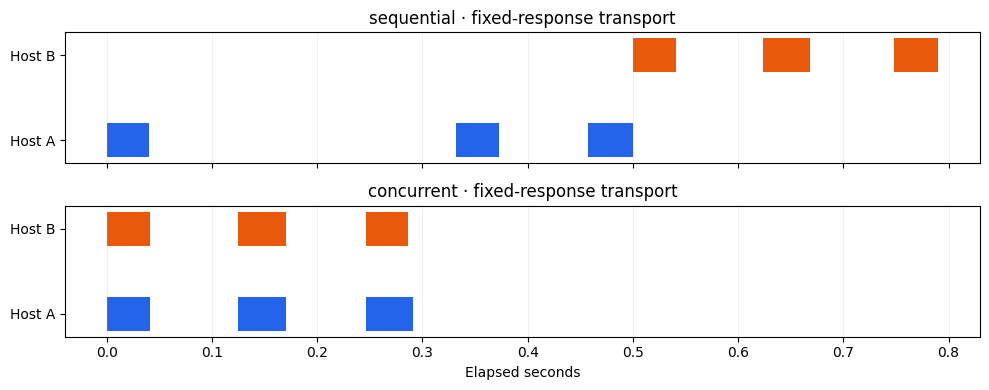

**해석:** 응답 집합이 같은 시험에서 순차 0.791초, 동시 0.292초였고 호스트 간격 위반은 0회였다. 이는 동시 대기 방식의 증거이며 실 네트워크의 속도 향상률은 아니다.

In [5]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
for ax, mode in zip(axes, ('sequential','concurrent')):
    for row, (host, spans) in enumerate(retry_evidence['concurrency'][mode + '_log'].items()):
        ax.broken_barh([(a, b-a) for a,b in spans], (row-.2, .4),
                      facecolors='#2563eb' if host == 'A' else '#ea580c')
    ax.set_yticks([0,1], ['Host A','Host B'])
    ax.set_title(mode + ' · fixed-response transport')
    ax.grid(axis='x', alpha=.18)
axes[-1].set_xlabel('Elapsed seconds')
fig.tight_layout()
(ROOT / 'reports/figures').mkdir(parents=True, exist_ok=True)
fig.savefig(ROOT / 'reports/figures/concurrency_gantt.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
bench = retry_evidence['concurrency']
display(Markdown(f"**해석:** 응답 집합이 같은 시험에서 순차 {bench['sequential_s']:.3f}초, "
    f"동시 {bench['concurrent_s']:.3f}초였고 호스트 간격 위반은 {bench['interval_violations']}회였다. "
    '이는 동시 대기 방식의 증거이며 실 네트워크의 속도 향상률은 아니다.'))

## 3. 원본·정제·관측 분리와 계보

`raw_listing_page`는 요청 단위와 실패를 남긴다. 정제 공고는 플랫폼 자연키로 upsert하고, 관측 테이블은 공고가 실제 보인 실행·직무·페이지를 기록한다. `raw_id`와 실행 키를 통해 정제 결과를 원본으로 추적한다. 기술 키워드는 별도 테이블에 저장하고 플랫폼 간 중복 매핑은 `posting_canonical`에 남긴다.

**SQL 목적:** 원본과 정제의 저장 구조를 보여주고, 표본 정제 공고가 원본·시간별 관측·통합 ID에 연결되는지 검증한다. 원본 본문·인증 정보는 출력하지 않는다.

In [6]:
tables = query("SELECT table_name,table_type FROM information_schema.tables "
               "WHERE table_schema='public' ORDER BY table_type,table_name")
display(tables)
display(query("SELECT table_name,column_name,data_type FROM information_schema.columns "
    "WHERE table_schema='public' AND table_name IN ('raw_listing_page','job_posting','posting_snapshot') "
    "AND column_name IN ('raw_id','run_key','platform','posting_id','job_group','body','body_sha256','last_raw_id') "
    "ORDER BY table_name,ordinal_position"))
lineage_sql = '''SELECT s.run_key,s.raw_id,r.body_sha256,s.platform,s.posting_id,s.job_group,
       p.company_name,p.title,pc.canonical_id
FROM posting_snapshot s JOIN raw_listing_page r USING (raw_id)
JOIN job_posting p ON p.platform=s.platform AND p.posting_id=s.posting_id
LEFT JOIN posting_canonical pc ON pc.platform=p.platform AND pc.posting_id=p.posting_id
WHERE s.run_key=%s ORDER BY s.platform,s.posting_id,s.job_group LIMIT 8'''
lineage = sql_evidence(lineage_sql, (RUN_KEY,))
integrity = query('''SELECT count(*) AS observations,
    count(*) FILTER (WHERE r.raw_id IS NULL) AS missing_raw,
    count(*) FILTER (WHERE p.posting_id IS NULL) AS missing_master,
    count(*) FILTER (WHERE pc.canonical_id IS NULL) AS missing_canonical
FROM v_snapshot_scope s LEFT JOIN raw_listing_page r USING(raw_id)
LEFT JOIN job_posting p ON p.platform=s.platform AND p.posting_id=s.posting_id
LEFT JOIN posting_canonical pc ON pc.platform=s.platform AND pc.posting_id=s.posting_id''')
display(integrity)
assert integrity[['missing_raw','missing_master','missing_canonical']].to_numpy().sum() == 0

,table_name,table_type
0,crawl_run,BASE TABLE
1,job_canonical,BASE TABLE
2,job_posting,BASE TABLE
3,listing_metric,BASE TABLE
4,posting_canonical,BASE TABLE
5,posting_role,BASE TABLE
6,posting_skill,BASE TABLE
7,posting_snapshot,BASE TABLE
8,quality_check,BASE TABLE
9,raw_listing_page,BASE TABLE


,table_name,column_name,data_type
0,job_posting,platform,text
1,job_posting,posting_id,text
2,job_posting,last_raw_id,bigint
3,posting_snapshot,run_key,text
4,posting_snapshot,platform,text
5,posting_snapshot,job_group,text
6,posting_snapshot,posting_id,text
7,posting_snapshot,raw_id,bigint
8,raw_listing_page,raw_id,bigint
9,raw_listing_page,run_key,text


```sql
SELECT s.run_key,s.raw_id,r.body_sha256,s.platform,s.posting_id,s.job_group,
       p.company_name,p.title,pc.canonical_id
FROM posting_snapshot s JOIN raw_listing_page r USING (raw_id)
JOIN job_posting p ON p.platform=s.platform AND p.posting_id=s.posting_id
LEFT JOIN posting_canonical pc ON pc.platform=p.platform AND pc.posting_id=p.posting_id
WHERE s.run_key=%s ORDER BY s.platform,s.posting_id,s.job_group LIMIT 8
```

,run_key,raw_id,body_sha256,platform,posting_id,job_group,company_name,title,canonical_id
0,scheduled__2026-10-02T05:40:00+00:00,586,49ea89e1bb8276d967c56d64bee85d11208e5e5ca7dff754164256551760c338,incruit,2606130000077,DA,도쿄일렉트론코리아,도쿄일렉트론코리아 경력직 상시채용 공고_인재풀 등록,1
1,scheduled__2026-10-02T05:40:00+00:00,584,3b63c75e041d96945398c1c4ef9bbde4e3fd039746149b1a5ea63df4c0de2085,incruit,2606130000077,DE,도쿄일렉트론코리아,도쿄일렉트론코리아 경력직 상시채용 공고_인재풀 등록,1
2,scheduled__2026-10-02T05:40:00+00:00,584,3b63c75e041d96945398c1c4ef9bbde4e3fd039746149b1a5ea63df4c0de2085,incruit,2607060002877,DE,(주)안랩,[신입/경력] 디지털 포렌식,2
3,scheduled__2026-10-02T05:40:00+00:00,584,3b63c75e041d96945398c1c4ef9bbde4e3fd039746149b1a5ea63df4c0de2085,incruit,2607070001094,DE,한화에어로스페이스,[한화에어로스페이스] AI 인력 상시 경력 채용,3
4,scheduled__2026-10-02T05:40:00+00:00,586,49ea89e1bb8276d967c56d64bee85d11208e5e5ca7dff754164256551760c338,incruit,2607230003578,DA,(주)이노션,AI 엔지니어 (Data/Analytics),4
5,scheduled__2026-10-02T05:40:00+00:00,586,49ea89e1bb8276d967c56d64bee85d11208e5e5ca7dff754164256551760c338,incruit,2608040003533,DA,(주)이노션,데이터 분석 및 컨설팅 (Junior) (상시채용 인재풀),5
6,scheduled__2026-10-02T05:40:00+00:00,584,3b63c75e041d96945398c1c4ef9bbde4e3fd039746149b1a5ea63df4c0de2085,incruit,2608070000022,DE,삼양식품,[삼양식품] 글로벌 BI solution 개발 및 데이터 분석가,6
7,scheduled__2026-10-02T05:40:00+00:00,584,3b63c75e041d96945398c1c4ef9bbde4e3fd039746149b1a5ea63df4c0de2085,incruit,2608070000036,DE,(주)쏘카,데이터 프로덕트 매니저,7


,observations,missing_raw,missing_master,missing_canonical
0,21686,0,0,0


## 4. 같은 원본 두 번 적재·다른 실행 키

원본의 목록 고유키와 정제 공고의 자연키를 유지한다. `first_seen`/`last_seen`은 최소·최대 관측 시각이며 게시 시각은 더 정밀한 값만 반영한다. 같은 실행의 관측·완전성 지표는 다시 만들어 parser 수정 후 replay가 가능하다.

아래는 저장 원본으로 실제 정제를 두 번 실행한 행 수다. 원본 행 수는 시험 실행 키만, 정제·관측은 전체 행을 센다. 다른 실행 키의 실험은 rollback하여 분석 범위에 남기지 않는다. canonical을 두 번 생성하여 행 수와 매핑 지문도 비교한다. [시험 코드](scripts/evidence.py)는 전체 시험 동안 정제·통합 advisory lock을 유지하여 운영 수집의 새 원본과 시험 결과를 구분한다.

In [7]:
from evidence import verify_idempotency
idempotency = verify_idempotency()
display(pd.DataFrame({'전': idempotency['before'], '1차': idempotency['after_first'],
    '2차': idempotency['after_second'], '2차 증가': idempotency['increase_second']}))
display(pd.DataFrame([{'다른 run 마스터 증가': idempotency['new_run_master_growth'],
    '실험 rollback': idempotency['experiment_rolled_back'],
    '통합 행 수(1·2차)': idempotency['dedup']['canonical_rows'],
    '통합 매핑 지문 동일': idempotency['dedup']['mapping_fingerprint_equal']}]))
assert all(n == 0 for n in idempotency['increase_second'].values())
assert idempotency['new_run_master_growth'] == 0
assert idempotency['experiment_rolled_back'] and idempotency['dedup']['mapping_fingerprint_equal']
display(Markdown('**해석:** 동일 원본 반복 실행은 행을 늘리지 않았다. 다른 실행 키는 '
    '별도의 시간 관측을 만들 수 있지만 플랫폼 공고 마스터는 증가하지 않았다.'))

,전,1차,2차,2차 증가
raw_listing_page,12,12,12,0
raw_posting_detail,19,19,19,0
job_posting,4891,4891,4891,0
posting_role,5716,5716,5716,0
posting_snapshot,21686,21686,21686,0
listing_metric,100,100,100,0
posting_skill,3125,3125,3125,0


,다른 run 마스터 증가,실험 rollback,통합 행 수(1·2차),통합 매핑 지문 동일
0,0,True,"[4503, 4503]",True


**해석:** 동일 원본 반복 실행은 행을 늘리지 않았다. 다른 실행 키는 별도의 시간 관측을 만들 수 있지만 플랫폼 공고 마스터는 증가하지 않았다.

## 5. 플랫폼 간 중복 통합 기준

정규화 회사명, 제목 유사도 `τ=0.55`, 마감일 양쪽 NULL 또는 3일 이내, 지역 호환을 함께 적용한다. 프론트/백엔드·리더/엔지니어 등 직무 충돌을 제외한다. 괄호의 팀·브랜드 제거에서 오탐이 발견되어 괄호 내용을 보존했다.

임계값별 통합 규모로 민감도를 확인한다. 고정 표본의 AI 육안 검토는 정답 라벨이 아니므로 실제 정밀도나 재현율을 단정할 수 없다. 모든 플랫폼 출처를 남겨 원공고를 확인할 수 있다.

In [8]:
from evidence import threshold_evidence
sensitivity = threshold_evidence()
display(pd.DataFrame(sensitivity['thresholds']))
review = json.loads((ROOT / 'reports/dedup_review.json').read_text())
display(pd.DataFrame(review['sample'])[['company_a','title_a','title_b','similarity','label','review']]
        .groupby('label', dropna=False).head(2))
print('고정 검토 표본:', review['label_counts'])
print('검토 한계:', review['limitation'])

,tau,candidate_pairs,canonical_groups,cross_posted,cross_posted_ratio
0,0.40,436,4470,381,0.085235
1,0.50,416,4489,369,0.082201
2,0.55,399,4503,362,0.080391
3,0.60,385,4517,352,0.077928
4,0.70,354,4546,329,0.072371


,company_a,title_a,title_b,similarity,label,review
0,네이버클라우드 주식회사,[NAVER Cloud] AI Security 분야 채용 (경력),AI Security 분야 채용 (경력),0.555556,True,"같은 공고일 가능성이 높음: 회사·핵심 직무·마감 일치, 표현/회사 접두어 차이"
1,(재)건설산업정보원,(재)건설산업정보원 연구원 채용(정보시스템 운영 및 관리),연구원 모집 (정보시스템 운영 및 관리),0.615385,True,"같은 공고일 가능성이 높음: 회사·핵심 직무·마감 일치, 표현/회사 접두어 차이"
3,㈜스카이즈코리아,(주) 스카이즈코리아 AI테크팀(부산) 채용,(주) 스카이즈코리아 AI테크팀 (서울) 채용,0.727273,False,"다른 공고: 부산 팀과 서울 팀, 근무지 차이. 지역 호환 조건 추가로 배제"
4,에스케이브로드밴드,2026년 하반기 SK브로드밴드 Junior Talent 채용,2026년 하반기 SK브로드밴드 Junior Talent 채용(AT/DT),0.785714,None,"불확실: Junior Talent 전체와 AT/DT 세부 직군, 동일 채용의 범위인지 확인 필요"


고정 검토 표본: {'likely_same': 18, 'different': 1, 'uncertain': 1}
검토 한계: 정답 데이터가 없으므로 실제 매칭 정밀도를 단정하지 않음. 조정 전 고정 표본을 보존.


## 6. 품질 규칙·결측 원인

원천 성공 비율, 필수 값, 개인정보 패턴, 날짜·경력 유효성, 직전 총건수 30% 변화와 실행 지연을 점검한다. 전체 원천 실패·개인정보는 critical, 개별 원천·개별 데이터 문제는 warning으로 격리한다. [규칙 원문](src/jobtrend/quality.py)과 `quality_check`에 판정 이력을 남긴다.

학력·고용 형태는 목록에 없으면 결측이고, 경력 무관은 연수 결측일 수 있다. 상시·채용시 마감의 날짜 NULL은 의미 있는 상태다. 미상과 상시를 구분해야 하며 결측을 임의의 숫자·날짜로 채우지 않는다.

In [9]:
missingness = query((ROOT / 'sql/missingness.sql').read_text())
validity = query((ROOT / 'sql/validity.sql').read_text())
display(missingness)
display(validity)
latest_quality = query('SELECT check_name,platform,dimension,metric,threshold,severity,detail '
    'FROM quality_check WHERE run_key=%s ORDER BY severity,check_name,platform', (RUN_KEY,))
display(latest_quality)
assert validity.required_missing.sum() == 0
assert validity.sentinel_leaks.sum() == 0
privacy = query("SELECT coalesce(sum(metric),0) AS n FROM quality_check q JOIN v_run_scope r USING(run_key) "
                "WHERE check_name='privacy_patterns'")
assert float(privacy.iloc[0].n) == 0
warning_count = int(latest_quality.severity.eq('warning').sum())
critical_count = int(latest_quality.severity.eq('critical').sum())
display(Markdown(f'**해석:** 필수 값 결측 {int(validity.required_missing.sum())}건, '
    f'상시 마감 sentinel 유출 {int(validity.sentinel_leaks.sum())}건, '
    f'개인정보 검출 {float(privacy.iloc[0].n):g}건이다. 마지막 실행의 warning은 {warning_count}개, '
    f'critical은 {critical_count}개다. 원천별 결측률 차이는 제공 필드 차이와 상세 수집 한도를 반영한다.'))

,platform,n,posted_at,sido,career_min_yr,education,deadline_unknown,meaningful_deadline_null,employment_type
0,incruit,169,0.000000,0.029586,0.195266,0.000000,0.000000,0.544379,0.000000
1,jobkorea,2023,0.000000,0.007415,0.196738,0.035591,0.011864,0.153238,0.013347
2,linkareer,119,0.000000,0.008403,0.445378,0.075630,0.000000,0.579832,0.731092
3,saramin,2580,0.043023,0.009302,0.213178,0.000000,0.000000,0.196899,0.000388


,platform,n,deadline_before_posted,invalid_career,sentinel_leaks,required_missing
0,incruit,169,0,0,0,0
1,jobkorea,2023,0,0,0,0
2,linkareer,119,0,0,0,0
3,saramin,2580,0,0,0,0


,check_name,platform,dimension,metric,threshold,severity,detail
0,change_reported_total,incruit:BE,change,0,0.3,ok,"{'cur': 62, 'prev': 62}"
1,change_reported_total,jobkorea:BE,change,0.002,0.3,ok,"{'cur': 1611, 'prev': 1615}"
2,change_reported_total,jobkorea:DA,change,0,0.3,ok,"{'cur': 129, 'prev': 129}"
3,change_reported_total,jobkorea:DE,change,0,0.3,ok,"{'cur': 379, 'prev': 379}"
4,change_reported_total,linkareer:IT,change,0.009,0.3,ok,"{'cur': 473, 'prev': 469}"
5,change_reported_total,saramin:BE,change,0.002,0.3,ok,"{'cur': 1773, 'prev': 1769}"
6,change_reported_total,saramin:DA,change,0,0.3,ok,"{'cur': 675, 'prev': 675}"
7,change_reported_total,saramin:DE,change,0.001,0.3,ok,"{'cur': 787, 'prev': 786}"
8,completeness_required,*,completeness,0,0,ok,{}
9,coverage_any_ok,*,coverage,12,1,ok,{}


**해석:** 필수 값 결측 0건, 상시 마감 sentinel 유출 0건, 개인정보 검출 0건이다. 마지막 실행의 warning은 0개, critical은 0개다. 원천별 결측률 차이는 제공 필드 차이와 상세 수집 한도를 반영한다.

## 7. Airflow·관측 커버리지·복구

`open_run → extract_raw → transform_load(all_done) → resolve_duplicates → check_quality → route → finish / alert_and_fail`

평일 09:00~20:00 KST의 10분 간격은 67틱이다. XCom은 요약만 전달하고 원본은 PostgreSQL에 저장한다. 실제 가동 전 오전 23틱은 좌절단으로 남긴다. 미래·진행 중·운영 중 누락을 분리하며, 없는 오전 관측을 사후 값으로 채우지 않는다.

13:50 실행에서는 구조화된 학력 JSON의 파싱 오류를 수정하고 보존 원본으로 재실행했다. 아래는 복구 기록과 해당 실행의 현재 상태다. DAG 구조는 로컬 커널과 실제 Airflow 컨테이너에서 각각 확인한다.

In [10]:
from test_dag import verify
schedule_evidence = verify()
container_test = 'import sys\nsys.path.insert(0, "/opt/airflow/dags")\n' + (ROOT / 'tests/test_dag.py').read_text()
container_run = subprocess.run(['docker','exec','-i','job-platform-pipeline-airflow-scheduler-1','python','-'],
    input=container_test, text=True, capture_output=True, check=True)
container_schedule = next(json.loads(line) for line in container_run.stdout.splitlines()
                          if line.startswith('{"ticks"'))
assert schedule_evidence['ticks'] == container_schedule['ticks'] == 67
assert set(schedule_evidence['tasks']) == set(container_schedule['tasks'])
display(pd.DataFrame([{'환경': '노트북 커널', **schedule_evidence},
                      {'환경': 'Airflow 컨테이너', **container_schedule}]))
dag_path = ROOT / 'src/jobtrend_dag.py'
deployed_dag = ROOT / 'airflow/dags/jobtrend_dag.py'
dag_source_equal = dag_path.read_bytes() == deployed_dag.read_bytes()
print('로컬/배포 DAG 파일 동일:', dag_source_equal)
assert dag_source_equal
display(pd.DataFrame([json.loads((ROOT / 'reports/deployment.json').read_text())]))

import operations
ops = operations.state()
display(pd.DataFrame(ops['counts'].items(), columns=['슬롯 상태','개수']).sort_values('슬롯 상태'))
problem_slots = pd.DataFrame(ops['slots'])
display(problem_slots[problem_slots.state.isin(['MISSING','FAILED','RUNNING','GRACE'])])
display(pd.DataFrame(ops['requests']))
print('점검 시각:', ops['checked_at'], '· DAG paused:', ops['dag_paused'],
      '· import 오류:', ops['import_errors'])
assert ops['import_errors'] == 0
recovery = json.loads((ROOT / 'reports/recovery.json').read_text())
display(pd.DataFrame([recovery]))
recovered = query('SELECT run_key,slot_ts,status,finished_at FROM crawl_run WHERE run_key=%s',
                  (recovery['run_id'],))
display(recovered)
assert len(recovered) == 1 and recovered.iloc[0].status in ('success','partial')
display(Markdown('**해석:** 좌절단은 가동 전 공백이며 운영 중 누락과 구별한다. '
    '13:50 파싱 실패는 원본이 남아 있어 재정제·재실행으로 복구할 수 있었다. '
    '현재 슬롯별 상태는 위 점검 시각의 결과다.'))

{"ticks": 67, "first": "2026-10-02T09:00:00+09:00", "last": "2026-10-02T20:00:00+09:00", "tasks": ["check_quality", "open_run", "extract_raw", "transform_load", "resolve_duplicates", "route", "alert_and_fail", "finish"], "max_active_runs": 1}


,환경,ticks,first,last,tasks,max_active_runs
0,노트북 커널,67,2026-10-02T09:00:00+09:00,2026-10-02T20:00:00+09:00,"[check_quality, open_run, extract_raw, transform_load, resolve_duplicates, route,...",1
1,Airflow 컨테이너,67,2026-10-02T09:00:00+09:00,2026-10-02T20:00:00+09:00,"[check_quality, open_run, extract_raw, transform_load, resolve_duplicates, route,...",1


로컬/배포 DAG 파일 동일: True


,files,code_version,running_after
0,20,25c37fd3771c,0


,슬롯 상태,개수
0,FUTURE,32
1,LEFT_TRUNCATED,23
2,SUCCESS,12


...

,platform,attempts,retried_pages
0,incruit,37,2
1,jobkorea,159,0
2,linkareer,53,0
3,saramin,126,0


점검 시각: 2026-10-02T14:44:23.493403+09:00 · DAG paused: False · import 오류: 0


,run_id,cause,action,api_status
0,scheduled__2026-10-02T04:50:00+00:00,educationRequirements JSON object,parse fix and rerun cached raw on latest version,200


,run_key,slot_ts,status,finished_at
0,scheduled__2026-10-02T04:50:00+00:00,2026-10-02 13:50:00+09:00,success,2026-10-02 14:44:09.293982+09:00


**해석:** 좌절단은 가동 전 공백이며 운영 중 누락과 구별한다. 13:50 파싱 실패는 원본이 남아 있어 재정제·재실행으로 복구할 수 있었다. 현재 슬롯별 상태는 위 점검 시각의 결과다.

## 8. 재현 경로·현재 검증 결과

정제와 DAG는 동일한 [jobtrend 패키지](src/jobtrend/)를 import한다. 원문을 반복 생성하는 셀 대신 모듈 파일과 지문을 남긴다. [수집](src/jobtrend/collect.py) · [HTTP](src/jobtrend/http.py) · [정제](src/jobtrend/transform.py) · [통합](src/jobtrend/dedup.py) · [DDL](src/jobtrend/schema.sql) · [DAG](src/jobtrend_dag.py) · [멱등 시험](scripts/evidence.py)

재현은 프로젝트 폴더에서 `python scripts/build_etl_notebook.py`로 생성하고 두 노트북의 전체 셀을 새 커널에서 실행한다. 운영 환경 설정과 실행 방법은 README를 따른다. 노트북 실행 결과와 검증 JSON을 함께 보존한다.

금요일 하루·미가동 오전 공백·직무 코드의 범위 차이·동적으로 변하는 목록·중복 판정의 불확실성이 남는다. 20:00 슬롯을 확인하기 전에는 부분 데이터다. ETL 시험 성공과 하루 관측 완료를 별도로 표시한다.

In [11]:
manifest_paths = sorted((ROOT / 'src').rglob('*.py')) + sorted((ROOT / 'src').rglob('*.sql'))
manifest_paths += [ROOT / 'scripts/evidence.py', ROOT / 'tests/test_pipeline.py', ROOT / 'tests/test_dag.py']
manifest = [{'file': p.relative_to(ROOT).as_posix(), 'sha256': hashlib.sha256(p.read_bytes()).hexdigest()}
            for p in manifest_paths if '__pycache__' not in p.parts]
display(pd.DataFrame(manifest).assign(sha256=lambda df: df.sha256.str[:12]))
(ROOT / 'reports/source_manifest.json').write_text(json.dumps(manifest, ensure_ascii=False, indent=2))

final_slot = query("SELECT status FROM crawl_run WHERE run_kind='scheduled' "
                   "AND slot_ts=timestamptz '2026-10-02 20:00+09'")
finished = not final_slot.empty and final_slot.iloc[0].status in ('success','partial')
checks = {
    '4개 원천 실제 200·재파싱': set(smoke['원천']) == set(REGISTRY),
    '실패·동시성 7개 시험': retry_evidence['tests']['failures'] == retry_evidence['tests']['errors'] == 0,
    '원본·정제·통합 계보': integrity[['missing_raw','missing_master','missing_canonical']].to_numpy().sum() == 0,
    '2회 적재 증가 0': all(n == 0 for n in idempotency['increase_second'].values()),
    '다른 실행 키 rollback': idempotency['experiment_rolled_back'],
    '통합 매핑 멱등': idempotency['dedup']['mapping_fingerprint_equal'],
    '커널·컨테이너 67틱': schedule_evidence['ticks'] == container_schedule['ticks'] == 67,
    '필수 값·sentinel·개인정보': validity.required_missing.sum() == validity.sentinel_leaks.sum() == float(privacy.iloc[0].n) == 0,
    'DAG import 오류 0': ops['import_errors'] == 0,
    '13:50 실행 복구': recovered.iloc[0].status in ('success','partial'),
}
checks = {k: bool(v) for k,v in checks.items()}
assert all(checks.values()), checks
display(pd.DataFrame(checks.items(), columns=['검증 항목','통과']))
display(Markdown('**' + ('20:00 최종 슬롯 확인' if finished else '부분 수집 데이터 · 20:00 슬롯 대기')
    + '** · 관측 기준 ' + ASOF))
result = {'asof': ASOF, 'code_version': CODE_VERSION, 'final_slot': bool(finished),
          'checks': checks, 'coverage': ops['counts'], 'idempotency': idempotency,
          'dag_source_equal': dag_source_equal}
(ROOT / 'reports/etl_validation.json').write_text(json.dumps(result, ensure_ascii=False, indent=2, default=str))

,file,sha256
0,src/jobtrend/__init__.py,67f8fec2f84a
1,src/jobtrend/analysis.py,f1888d9a4acc
2,src/jobtrend/collect.py,c82d4e16e984
3,src/jobtrend/config.py,7de81c5a8bc0
4,src/jobtrend/dedup.py,ac442de4293f
5,src/jobtrend/http.py,a10a4c27df58
6,src/jobtrend/normalize.py,5826a4509c01
7,src/jobtrend/quality.py,931a9d42e266
8,src/jobtrend/runlog.py,e4b9d0cd6a5c
9,src/jobtrend/skills.py,977e75943a45


,검증 항목,통과
0,4개 원천 실제 200·재파싱,True
1,실패·동시성 7개 시험,True
2,원본·정제·통합 계보,True
3,2회 적재 증가 0,True
4,다른 실행 키 rollback,True
5,통합 매핑 멱등,True
6,커널·컨테이너 67틱,True
7,필수 값·sentinel·개인정보,True
8,DAG import 오류 0,True
9,13:50 실행 복구,True


**부분 수집 데이터 · 20:00 슬롯 대기** · 관측 기준 2026-10-02 14:40:00+09:00

1688